# Лабораторная работа — Классификация в машинном обучении
**Выполнил:** Медведь Е.Ю. ИСУ 368509
**Дисциплина:** Методы искусственного интеллекта  
**Тема:** Классификация текстовых новостей (AG News)
**Датасет:** `datasets.load_dataset('ag_news')`  
- Тип данных: текст  
- Размер: 120 000 train, 7 600 test  
- Классы: 4 (World, Sports, Business, Science/Tech)  





## 1) Импорт библиотек

In [ ]:
!pip -q install datasets transformers scikit-learn matplotlib pandas numpy

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 4)


## 2) Загрузка и исследование датасета (AG News)

In [ ]:
dataset = load_dataset("ag_news")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [ ]:
# Посмотрим структуру
print(dataset)
print("Train size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))
print("Columns:", dataset["train"].column_names)

# Пример записи
dataset["train"][0]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train size: 120000
Test size: 7600
Columns: ['text', 'label']


{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

### 2.1 Преобразование в DataFrame для удобства EDA

In [ ]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])

train_df["label_name"] = train_df["label"].map(label_names)
test_df["label_name"]  = test_df["label"].map(label_names)

train_df.head()

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## 3) Разведочный анализ данных (EDA)

### 3.1 Распределение классов

In [ ]:
class_counts = train_df["label_name"].value_counts().sort_index()
class_counts

,count
label_name,
Business,30000
Sci/Tech,30000
Sports,30000
World,30000


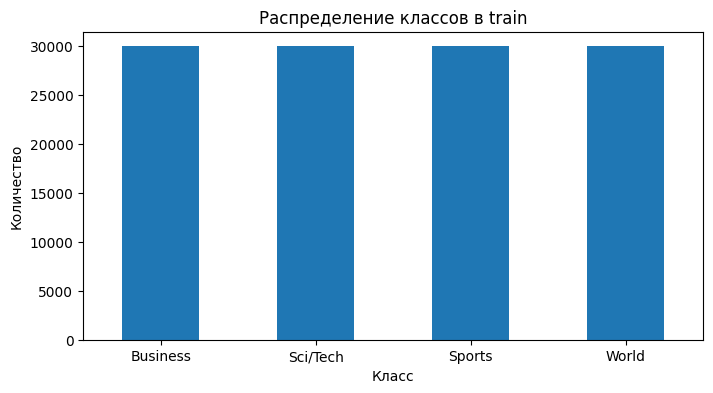

In [ ]:
plt.figure()
class_counts.plot(kind="bar")
plt.title("Распределение классов в train")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

### 3.2 Длина текстов (кол-во символов и слов)

In [ ]:
train_df["char_len"] = train_df["text"].str.len()
train_df["word_len"] = train_df["text"].str.split().apply(len)

train_df[["char_len", "word_len"]].describe()

,char_len,word_len
count,120000.000000,120000.000000
mean,236.477525,37.847450
std,66.509741,10.085245
min,100.000000,8.000000
25%,196.000000,32.000000
50%,232.000000,37.000000
75%,266.000000,43.000000
max,1012.000000,177.000000


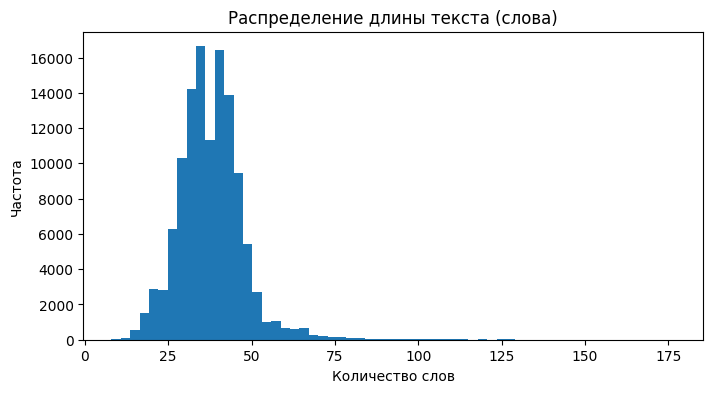

In [ ]:
plt.figure()
plt.hist(train_df["word_len"], bins=60)
plt.title("Распределение длины текста (слова)")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.show()

### 3.3 Примеры текстов по классам

In [ ]:
for lbl, name in label_names.items():
    example = train_df.loc[train_df["label"] == lbl, "text"].sample(1, random_state=RANDOM_STATE).values[0]
    print(f"== {name} ==")
    print(example[:400].replace("\n", " "))

== World ==
Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.
== Sports ==
Second Andre win in a row boosts US gold medal hopes Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United States of at least two boxing medals Wednesday by narrowly beating Cuba #39;s Yordani Despaigne to advance to the Olympic middleweight semifinals.
== Business ==
US house sales fall in July Sales of non-new houses in the US fell last month but still exceeded analyst forecasts.
== Sci/Tech ==
Gartner optimistic about chip numbers But that optimism isn #39;t matched by Infineon, which said that while the market worldwide remains buoyant, the US is a special case and cautioned that growth might not be as strong as it expected.


## 4) Предобработка текста

Для классических моделей машинного обучения (LogReg/SVM/Naive Bayes/RandomForest) обычно используется векторизация текста. В работе применим **TF‑IDF**.

Дополнительно сделаем простую очистку: приведение к нижнему регистру, удаление ссылок/чисел/лишней пунктуации.

In [ ]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text) # ссылки
    text = re.sub(r"\d+", " ", text)              # числа
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# проверка на примере
sample = train_df["text"].iloc[0]
print("BEFORE:", sample[:200])
print("AFTER: ", clean_text(sample)[:200])

BEFORE: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
AFTER:  wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again


In [ ]:
# Применим очистку
train_df["text_clean"] = train_df["text"].apply(clean_text)
test_df["text_clean"]  = test_df["text"].apply(clean_text)

train_df[["text", "text_clean"]].head()

,text,text_clean
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to alltime record posing new m...


## 5) Разделение на train/val/test

Так как в `ag_news` уже есть готовый `test`, корректно:
- использовать `train`: разделить на **train/val**,
- `test` оставить только для финальной оценки лучшей модели.

In [ ]:
X = train_df["text_clean"].values
y = train_df["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_test = test_df["text_clean"].values
y_test = test_df["label"].values

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

Train: 96000 Val: 24000 Test: 7600


## 6) Реализация базовых моделей

Требование: минимум 3 алгоритма классификации:
1) Логистическая регрессия
2) Случайный лес
3) SVM
и **дополнительный** алгоритм — Наивный Байес.

Все модели оформим в `Pipeline`, чтобы векторизация TF‑IDF выполнялась внутри пайплайна (это снижает риск утечки данных и упрощает GridSearchCV).

In [ ]:
tfidf = TfidfVectorizer(
    max_features=80_000,
    ngram_range=(1, 2),
    stop_words="english"  # для английского текста
)

models = {
    "LogReg": Pipeline([
        ("tfidf", tfidf),
        ("clf", LogisticRegression(max_iter=2000, n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    "LinearSVM": Pipeline([
    ("tfidf", tfidf),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(random_state=RANDOM_STATE),
        method="sigmoid",
        cv=3
    ))
    ]),
    # RandomForest не умеет работать с очень разреженными высокоразмерными матрицами эффективно.
    # Поэтому добавим SVD (LSA), чтобы понизить размерность.
    "RandomForest+SVD": Pipeline([
        ("tfidf", tfidf),
        ("svd", TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "MultinomialNB": Pipeline([
        ("tfidf", tfidf),
        ("clf", MultinomialNB())
    ])
}

list(models.keys())

['LogReg', 'LinearSVM', 'RandomForest+SVD', 'MultinomialNB']

## 7) Оценка моделей (Accuracy, Precision/Recall/F1, Confusion Matrix, Report, ROC-AUC)

MODEL: LogReg
Accuracy: 0.9226
Precision(macro): 0.9224
Recall(macro):    0.9226
F1(macro):        0.9224
Classification report:
               precision    recall  f1-score   support

       World       0.93      0.91      0.92      6000
      Sports       0.96      0.98      0.97      6000
    Business       0.90      0.90      0.90      6000
    Sci/Tech       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



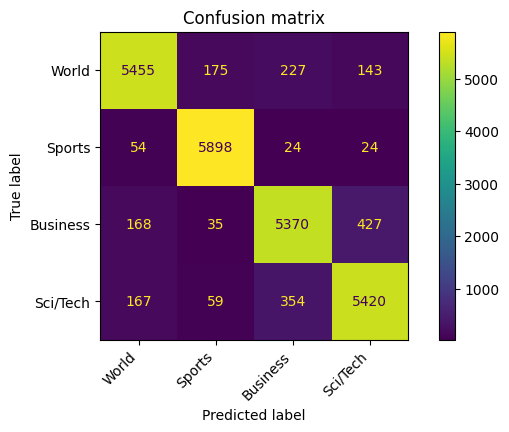

ROC-AUC(macro, ovr): 0.9857
MODEL: LinearSVM
Accuracy: 0.9263
Precision(macro): 0.9262
Recall(macro):    0.9263
F1(macro):        0.9262
Classification report:
               precision    recall  f1-score   support

       World       0.93      0.91      0.92      6000
      Sports       0.96      0.98      0.97      6000
    Business       0.90      0.90      0.90      6000
    Sci/Tech       0.91      0.91      0.91      6000

    accuracy                           0.93     24000
   macro avg       0.93      0.93      0.93     24000
weighted avg       0.93      0.93      0.93     24000



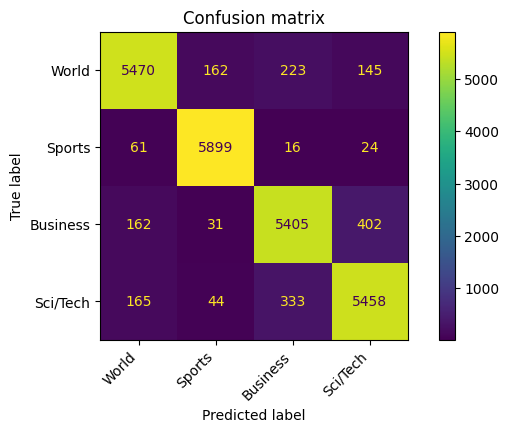

ROC-AUC(macro, ovr): 0.9868
MODEL: RandomForest+SVD
Accuracy: 0.8832
Precision(macro): 0.8829
Recall(macro):    0.8832
F1(macro):        0.883
Classification report:
               precision    recall  f1-score   support

       World       0.89      0.88      0.89      6000
      Sports       0.93      0.95      0.94      6000
    Business       0.85      0.85      0.85      6000
    Sci/Tech       0.86      0.85      0.85      6000

    accuracy                           0.88     24000
   macro avg       0.88      0.88      0.88     24000
weighted avg       0.88      0.88      0.88     24000



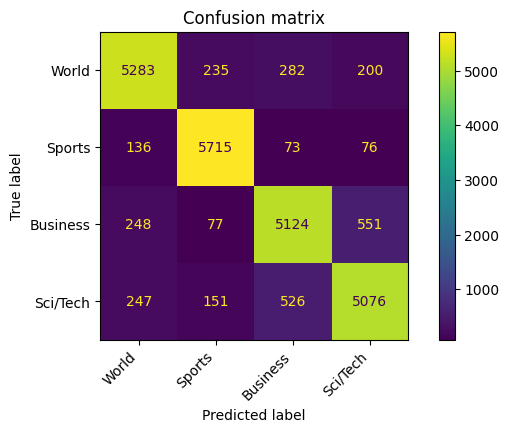

ROC-AUC(macro, ovr): 0.9761
MODEL: MultinomialNB
Accuracy: 0.915
Precision(macro): 0.9147
Recall(macro):    0.915
F1(macro):        0.9147
Classification report:
               precision    recall  f1-score   support

       World       0.92      0.90      0.91      6000
      Sports       0.95      0.98      0.97      6000
    Business       0.89      0.88      0.89      6000
    Sci/Tech       0.89      0.90      0.89      6000

    accuracy                           0.92     24000
   macro avg       0.91      0.92      0.91     24000
weighted avg       0.91      0.92      0.91     24000



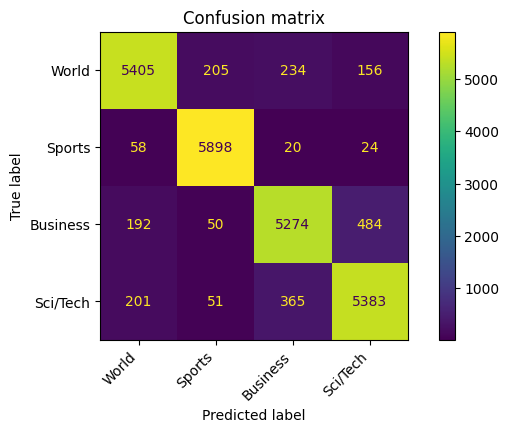

ROC-AUC(macro, ovr): 0.9809


,accuracy,precision_macro,recall_macro,f1_macro,model
1,0.926333,0.926183,0.926333,0.926192,LinearSVM
0,0.922625,0.922448,0.922625,0.922450,LogReg
3,0.915000,0.914704,0.915000,0.914729,MultinomialNB
2,0.883250,0.882888,0.883250,0.882993,RandomForest+SVD


In [ ]:
def evaluate_model(model, X_tr, y_tr, X_ev, y_ev, label_names_map):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)

    acc = accuracy_score(y_ev, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_ev, y_pred, average="macro", zero_division=0)

    print("Accuracy:", round(acc, 4))
    print("Precision(macro):", round(prec, 4))
    print("Recall(macro):   ", round(rec, 4))
    print("F1(macro):       ", round(f1, 4))
    print("Classification report:\n", classification_report(
        y_ev, y_pred, target_names=[label_names_map[i] for i in sorted(label_names_map.keys())], zero_division=0
    ))

    cm = confusion_matrix(y_ev, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names_map[i] for i in sorted(label_names_map.keys())])
    disp.plot(values_format="d")
    plt.title("Confusion matrix")
    plt.xticks(rotation=45, ha="right")
    plt.show()

    # ROC-AUC для многоклассовой классификации:
    # требуется либо predict_proba (для LR/NB/RF), либо decision_function (для LinearSVC).
        # ROC-AUC для многоклассовой классификации (требуются вероятности по классам)
    try:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_ev)  # shape (n_samples, n_classes), rows sum to 1
            auc = roc_auc_score(y_ev, proba, multi_class="ovr", average="macro")
            print("ROC-AUC(macro, ovr):", round(auc, 4))
        else:
            print("ROC-AUC не посчитан: у модели нет predict_proba()")
    except Exception as e:
        print("ROC-AUC не посчитан:", repr(e))

    return {"accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1}

results = []
for name, model in models.items():
    print("="*80)
    print("MODEL:", name)
    metrics = evaluate_model(model, X_train, y_train, X_val, y_val, label_names)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df

### 7.1 Краткое сравнение моделей на валидации

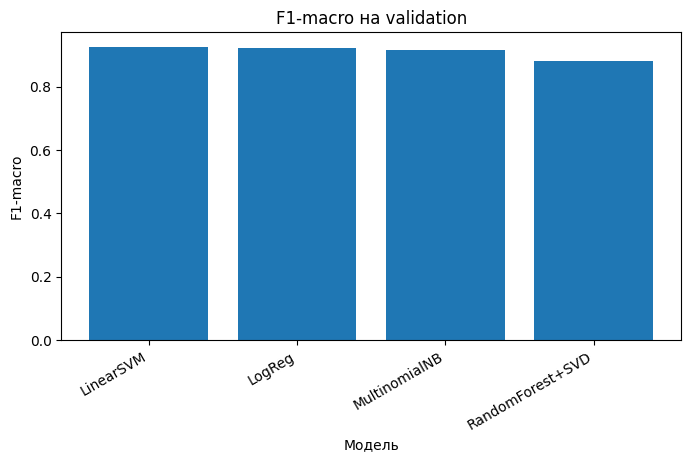

,accuracy,precision_macro,recall_macro,f1_macro,model
1,0.926333,0.926183,0.926333,0.926192,LinearSVM
0,0.922625,0.922448,0.922625,0.922450,LogReg
3,0.915000,0.914704,0.915000,0.914729,MultinomialNB
2,0.883250,0.882888,0.883250,0.882993,RandomForest+SVD


In [ ]:
plt.figure()
plt.bar(results_df["model"], results_df["f1_macro"])
plt.title("F1-macro на validation")
plt.xlabel("Модель")
plt.ylabel("F1-macro")
plt.xticks(rotation=30, ha="right")
plt.show()

results_df

## 8) Настройка гиперпараметров (GridSearchCV)

Далее выполним GridSearchCV для лучших (обычно — LogReg или LinearSVM). Сделаем умеренную сетку параметров, чтобы вычисления оставались разумными.

Используем **StratifiedKFold** и метрику `f1_macro`.

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Grid для Logistic Regression
logreg_pipe = models["LogReg"]
param_grid_logreg = {
    "tfidf__max_features": [50_000, 80_000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.5, 1.0, 2.0],
    "clf__solver": ["liblinear", "saga"]
}

grid_logreg = GridSearchCV(
    logreg_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(X_train, y_train)

print("Best params:", grid_logreg.best_params_)
print("Best CV score (f1_macro):", round(grid_logreg.best_score_, 4))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'clf__C': 2.0, 'clf__solver': 'saga', 'tfidf__max_features': 80000, 'tfidf__ngram_range': (1, 2)}
Best CV score (f1_macro): 0.9174


Accuracy: 0.9239
Precision(macro): 0.9237
Recall(macro):    0.9239
F1(macro):        0.9238
Classification report:
               precision    recall  f1-score   support

       World       0.93      0.91      0.92      6000
      Sports       0.96      0.98      0.97      6000
    Business       0.90      0.90      0.90      6000
    Sci/Tech       0.90      0.91      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



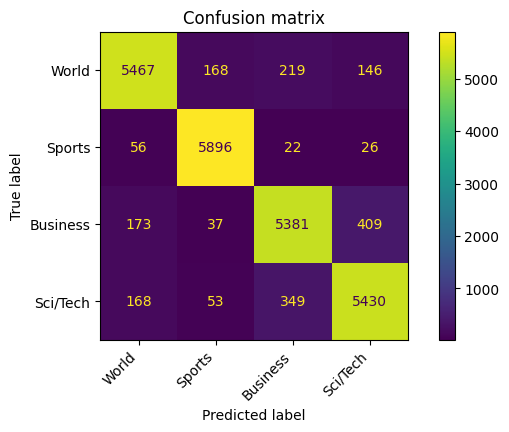

ROC-AUC(macro, ovr): 0.9865


{'accuracy': 0.9239166666666667,
 'precision_macro': 0.9237269425991091,
 'recall_macro': 0.9239166666666667,
 'f1_macro': 0.923751068106256}

In [ ]:
# Оценка лучшей модели на validation
best_logreg = grid_logreg.best_estimator_
val_metrics = evaluate_model(best_logreg, X_train, y_train, X_val, y_val, label_names)
val_metrics

### 8.1 Финальная оценка на тестовой выборке

После выбора лучшей конфигурации по CV и проверки на validation, оцениваем качество **на test**.

Важно: не подбирать параметры по test, иначе тест перестаёт быть независимой оценкой.

Accuracy: 0.9216
Precision(macro): 0.9215
Recall(macro):    0.9216
F1(macro):        0.9215
Classification report:
               precision    recall  f1-score   support

       World       0.94      0.91      0.93      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



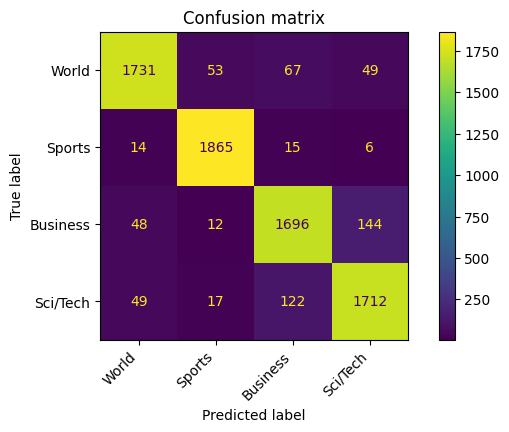

ROC-AUC(macro, ovr): 0.9847


{'accuracy': 0.921578947368421,
 'precision_macro': 0.9215302388342377,
 'recall_macro': 0.921578947368421,
 'f1_macro': 0.9214609559212954}

In [ ]:
test_metrics = evaluate_model(best_logreg, X_train, y_train, X_test, y_test, label_names)
test_metrics

## 9) Выводы

1. Датасет AG News содержит 4 класса новостей и достаточно хорошо сбалансирован, что упрощает обучение и сравнение моделей.
2. Для текстовой классификации классические линейные модели с TF‑IDF обычно показывают сильные результаты: Logistic Regression и Linear SVM часто оказываются лучшими по F1.
3. Случайный лес на разреженных текстовых признаках работает хуже и требует понижения размерности (SVD), иначе обучение будет медленным и неустойчивым.
4. Настройка гиперпараметров (C, n-gram, max_features и т.п.) влияет на качество: обычно биграммы и достаточное число признаков повышают качество, но могут ухудшать скорость.
5. Для воспроизводимости во всех процедурах использован `random_state=42`, а оценка качества выполнена на validation и независимом test.

**Итог:** построен полный ML-пайплайн для текстовой классификации: EDA - предобработка - базовые модели - оценка метрик - GridSearchCV - финальная проверка на test.